In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

# **LLM Schema**

In [2]:
from pydantic import BaseModel, Field
from typing import Literal
class llm_schema(BaseModel):
    funny_flag: Literal["Funny","Not Funny"] = Field(description="Is the joke produced by llm funny of not")
    feedback: str = Field(description="Give a solid reason on why this joke is not funny and provide ways of improvment")

model_with_schema = model.with_structured_output(llm_schema)

# **Graph Schema**

In [3]:
class graph_schema(BaseModel):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

# **Generator Node**

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
def generator(state : graph_schema) -> graph_schema:
    topic = state.topic

    if state.feedback:
        joke = model.invoke(f"Please improve on this joke: {state.joke} for the feedback: {state.feedback}").content
    else:
        joke = model.invoke(f"Write a joke on {topic}").content

    state.joke = joke

    return state

# **Evaluator Node**

In [5]:
def evaluator(state : graph_schema) -> graph_schema:
    joke = state.joke
    iteration = state.max_iterations

    prompt = ChatPromptTemplate(
        [
            ("system","You are professional comedian and a critique judge the given joke and provide feed back on it"),
            ("user",f"{joke} Response with 'Funny' or 'Not Funny' and provide feed back if it is not funny")
        ]
    )

    chain = prompt | model_with_schema

    response = chain.invoke({'joke':joke})
    
    state.funny_flag = response.funny_flag
    state.feedback = response.feedback

    state.max_iterations = iteration + 1;

    return state

    

# **Iteration Counter**

In [ ]:
def need_evaluator(state:graph_schema) -> str:
    iteration = state.max_iterations

    if iteration <= 5 and state.funny_flag == "Not Funny":
        return "evaluator"
    else:
        return "end"

## **Node and Edges**

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("generator",generator)
graph.add_node("evaluator",evaluator)

graph.add_edge(START, "generator")
graph.add_conditional_edges("generator",need_evaluator,{"evaluator":"evaluator","end":END})
graph.add_edge("evaluator","generator")
graph.add_edge("evaluator",END)

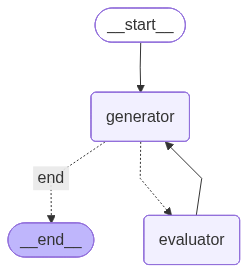

In [8]:
from IPython.display import Image,display

eval_optimize_graph = graph.compile()

Image(eval_optimize_graph.get_graph().draw_mermaid_png())

In [9]:
for chunk in eval_optimize_graph.invoke(
    {
        "topic":"Ai",
        "joke":"",
        "funny_flag":"",
        "feedback":"",
        "max_iterations":0
    },
    stream_mode="updates"
):
    print(chunk)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 57.55065249s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerMo